In [1]:
!git clone https://github.com/relatable52/EMG_motion_prediction

Cloning into 'EMG_motion_prediction'...
remote: Enumerating objects: 338, done.
remote: Total 338 (delta 0), reused 0 (delta 0), pack-reused 338 (from 1)
Receiving objects: 100% (338/338), 132.89 KiB | 7.38 MiB/s, done.
Resolving deltas: 100% (224/224), done.


In [2]:
!pip install gpytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 14.9 MB/s eta 0:00:00


In [3]:
%cd /kaggle/working/EMG_motion_prediction/src

/kaggle/working/EMG_motion_prediction/src


In [4]:
!mkdir /kaggle/temp

In [5]:
%%writefile /kaggle/working/EMG_motion_prediction/.env
DATA_DIR = /kaggle/input/ga-tech-emg-dataset
RESULTS_DIR = /kaggle/temp/results
LOG_DIR = /kaggle/working/logs
MODEL_DIR = /kaggle/working/models
CACHE_DIR = /kaggle/working/cache
EMG_FREQUENCY = 2000
ANGLE_FREQUENCY = 200
MPLBACKEND = 'Agg'

Writing /kaggle/working/EMG_motion_prediction/.env


In [6]:
!git pull origin master

From https://github.com/relatable52/EMG_motion_prediction
 * branch            master     -> FETCH_HEAD
Already up to date.


In [7]:
from dataset.utils import TRAIN_FILES, TEST_FILES

2026-04-13 20:15:39,353 - WARNING - Warning: Missing files for AB04 - normal_walk_1_0-6
2026-04-13 20:15:39,354 - WARNING - Warning: Missing files for AB04 - normal_walk_1_1-2
2026-04-13 20:15:39,356 - WARNING - Warning: Missing files for AB04 - normal_walk_1_1-8
2026-04-13 20:15:39,356 - WARNING - Warning: Missing files for AB04 - normal_walk_1_2-0
2026-04-13 20:15:39,357 - WARNING - Warning: Missing files for AB04 - normal_walk_1_2-5
2026-04-13 20:15:39,435 - WARNING - Warning: Missing files for AB07 - normal_walk_1_0-6
2026-04-13 20:15:39,437 - WARNING - Warning: Missing files for AB07 - normal_walk_1_1-2
2026-04-13 20:15:39,438 - WARNING - Warning: Missing files for AB07 - normal_walk_1_1-8
2026-04-13 20:15:39,439 - WARNING - Warning: Missing files for AB07 - normal_walk_1_2-0
2026-04-13 20:15:39,441 - WARNING - Warning: Missing files for AB07 - normal_walk_1_2-5


In [8]:
TEST_FILES

[{'subject': 'AB02',
  'activity': 'normal_walk_1_0-6',
  'emg_file': '/kaggle/input/ga-tech-emg-dataset/AB02/normal_walk_1_0-6/AB02_normal_walk_1_0-6_emg.csv',
  'angle_file': '/kaggle/input/ga-tech-emg-dataset/AB02/normal_walk_1_0-6/AB02_normal_walk_1_0-6_angle.csv'},
 {'subject': 'AB05',
  'activity': 'normal_walk_1_2-5',
  'emg_file': '/kaggle/input/ga-tech-emg-dataset/AB05/normal_walk_1_2-5/AB05_normal_walk_1_2-5_emg.csv',
  'angle_file': '/kaggle/input/ga-tech-emg-dataset/AB05/normal_walk_1_2-5/AB05_normal_walk_1_2-5_angle.csv'},
 {'subject': 'AB09',
  'activity': 'normal_walk_1_1-2',
  'emg_file': '/kaggle/input/ga-tech-emg-dataset/AB09/normal_walk_1_1-2/AB09_normal_walk_1_1-2_emg.csv',
  'angle_file': '/kaggle/input/ga-tech-emg-dataset/AB09/normal_walk_1_1-2/AB09_normal_walk_1_1-2_angle.csv'},
 {'subject': 'AB11',
  'activity': 'normal_walk_1_1-2',
  'emg_file': '/kaggle/input/ga-tech-emg-dataset/AB11/normal_walk_1_1-2/AB11_normal_walk_1_1-2_emg.csv',
  'angle_file': '/kaggle/i

In [9]:
import pandas as pd

for i in TEST_FILES:
    df = pd.read_csv(i['angle_file'])
    df_1 = pd.read_csv(i['emg_file'])
    print('hhhh', df['time'][:10], len(df))
    print(df_1['time'][:10], len(df_1))
    break

hhhh 0    10.000
1    10.005
2    10.010
3    10.015
4    10.020
5    10.025
6    10.030
7    10.035
8    10.040
9    10.045
Name: time, dtype: float64 4001
0    10.0000
1    10.0005
2    10.0010
3    10.0015
4    10.0020
5    10.0025
6    10.0030
7    10.0035
8    10.0040
9    10.0045
Name: time, dtype: float64 40001


In [10]:
import os
import sys
from pathlib import Path

import torch
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
from dotenv import load_dotenv

from dataset.prediction_dataset import PredictionDataset
from model.backbone import EMGScalogramBackbone

from utils.logger import logger

from scripts.train_and_test import (
    set_random_seeds     
)

In [ ]:
import torch.nn as nn

class DeterministicRegressor(nn.Module):
    def __init__(self, backbone: nn.Module, hidden_dim: int, output_dim: int = 1, dropout_rate: float = 0.2):
        """
        Standard MSE model. Also serves as the MC Dropout model during inference.
        """
        super().__init__()
        self.backbone = backbone
        
        # Projection head to map LSTM features to kinematic angles
        self.head = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim // 2, output_dim)
        )

    def forward(self, x):
        # x shape: (batch, n_channels, time, freq_scales)
        features = self.backbone(x)
        predictions = self.head(features)
        return predictions

class ProbabilisticRegressor(nn.Module):
    def __init__(self, backbone: nn.Module, hidden_dim: int, output_dim: int = 1):
        """
        Heteroscedastic Aleatoric model trained via NLL.
        """
        super().__init__()
        self.backbone = backbone
        
        self.feature_mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU()
        )
        
        # Outputs 2 * output_dim (one for mean, one for log-variance)
        self.output_layer = nn.Linear(hidden_dim // 2, output_dim * 2)

    def forward(self, x):
        features = self.backbone(x)
        hidden = self.feature_mlp(features)
        out = self.output_layer(hidden)
        
        # Split the output tensor into Mean and Log-Variance (unconstrained)
        mu, logvar = torch.chunk(out, 2, dim=-1)
        
        return mu, logvar

class DeepEnsembleRegressor(nn.Module):
    def __init__(self, backbone_factory, num_models: int, hidden_dim: int, output_dim: int = 1):
        """
        Ensemble of entirely independent Deterministic networks.
        """
        super().__init__()
        self.num_models = num_models
        
        # Initialize N separate models from scratch
        self.models = nn.ModuleList([
            DeterministicRegressor(
                backbone=backbone_factory(), 
                hidden_dim=hidden_dim, 
                output_dim=output_dim,
                dropout_rate=0.2 # Standard regularization during training
            ) 
            for _ in range(num_models)
        ])

    def forward(self, x):
        # Collect predictions from all independent models
        # Output shape: (num_models, batch_size, output_dim)
        ensemble_preds = torch.stack([model(x) for model in self.models])
        return ensemble_preds
    
    def predict_uncertainty(self, x):
        """Helper method for inference."""
        self.eval()
        with torch.no_grad():
            preds = self.forward(x)
            mean_pred = torch.mean(preds, dim=0)
            epistemic_var = torch.var(preds, dim=0)
            return mean_pred, epistemic_var

In [12]:
import gpytorch

class GPFeatureExtractor(nn.Module):
    def __init__(self, backbone: nn.Module, hidden_dim: int, latent_dim: int = 16):
        """
        Wraps the backbone and adds the crucial GP bottleneck.
        """
        super().__init__()
        self.backbone = backbone
        self.bottleneck = nn.Sequential(
            nn.Linear(hidden_dim, latent_dim),
            nn.ReLU()
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.bottleneck(features)
        
class DKLGaussianProcess(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, feature_extractor: nn.Module, latent_dim: int = 16, num_tasks: int = 2):
        # 1. Save the image dimensions so we can reconstruct them later
        self.original_shape = train_x.shape[1:] # e.g., (16, 200, 40)
        
        # 2. Flatten train_x to 2D [Samples, Features] to bypass GPyTorch's shape-checker
        train_x_flat = train_x.view(train_x.size(0), -1)
        
        super().__init__(train_x_flat, train_y, likelihood)
        
        self.feature_extractor = feature_extractor
        
        self.mean_module = gpytorch.means.MultitaskMean(
            gpytorch.means.ConstantMean(), num_tasks=num_tasks
        )
        base_kernel = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(ard_num_dims=latent_dim)
        )
        self.covar_module = gpytorch.kernels.MultitaskKernel(
            base_kernel, num_tasks=num_tasks, rank=1
        )

    def forward(self, x):
        # 3. Unflatten the 2D input back into the 4D tensor the CNN expects
        x_unflat = x.view(x.size(0), *self.original_shape)
        
        projected_x = self.feature_extractor(x_unflat)
        mean_x = self.mean_module(projected_x)
        covar_x = self.covar_module(projected_x)
        
        return gpytorch.distributions.MultitaskMultivariateNormal(mean_x, covar_x)

In [13]:
import os
from dataclasses import dataclass, field
from typing import List
from dotenv import load_dotenv

load_dotenv()

@dataclass
class EnvConfig:
    data_dir: str = os.getenv('DATA_DIR', '/kaggle/input/ga-tech-emg-dataset')
    results_dir: str = os.getenv('RESULTS_DIR', '/kaggle/temp/results')
    log_dir: str = os.getenv('LOG_DIR', '/kaggle/working/logs')
    model_dir: str = os.getenv('MODEL_DIR', '/kaggle/working/models')
    cache_dir: str = os.getenv('CACHE_DIR', '/kaggle/working/cache')
    emg_freq: int = int(os.getenv('EMG_FREQUENCY', 2000))
    angle_freq: int = int(os.getenv('ANGLE_FREQUENCY', 200))

@dataclass
class DataConfig:
    window_length: float = 1.0
    stride: float = 0.05
    prediction_horizon: float = 0.05
    # Use default_factory for mutable types like lists
    target_angle_name: List[str] = field(default_factory=lambda: ['knee_angle_r', 'knee_angle_l'])
    use_cache: bool = True
    output_fs: int = 100
    freq_min: float = 5.0
    freq_max: float = 450.0
    n_scales: int = 40

@dataclass
class ModelConfig:
    n_channels: int = 16
    n_freq_scales: int = 40  # Note: This should match DataConfig.n_scales!
    hidden_dim: int = 128
    output_dim: int = 1
    backbone_type: str = 'conv2d_lstm'
    dropout_rate: float = 0.2
    model_type: str = 'deterministic'
    num_ensembles: int = 20

@dataclass
class TrainConfig:
    batch_size: int = 32
    epochs: int = 20
    learning_rate: float = 5e-4
    weight_decay: float = 1e-5
    device: str = 'cuda' if torch.cuda.is_available() else 'cpu'
    log_interval: int = 10

@dataclass
class ExperimentConfig:
    env: EnvConfig = field(default_factory=EnvConfig)
    data: DataConfig = field(default_factory=DataConfig)
    model: ModelConfig = field(default_factory=ModelConfig)
    train: TrainConfig = field(default_factory=TrainConfig)
    
    def __post_init__(self):
        # Auto-sync model parameters with data parameters to prevent shape mismatches!
        self.model.n_freq_scales = self.data.n_scales
        self.model.output_dim = len(self.data.target_angle_name)

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import gpytorch
from tqdm.auto import tqdm

# --- Custom Loss Functions ---

def gaussian_nll_loss(mu: torch.Tensor, logvar: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    """Negative Log-Likelihood Loss for the Probabilistic (Aleatoric) Regressor."""
    # Convert log-variance to variance for NLL computation
    var = torch.exp(logvar)
    loss = 0.5 * logvar + 0.5 * ((target - mu) ** 2) / var
    return loss.mean()

def ensemble_mse_loss(ensemble_preds: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    """Computes MSE across all models in the Deep Ensemble simultaneously."""
    # Expand target to match the number of models: (num_models, batch_size, output_dim)
    target_expanded = target.unsqueeze(0).expand_as(ensemble_preds)
    return F.mse_loss(ensemble_preds, target_expanded)


# --- The Standard Neural Network Loop (Mini-Batched) ---

def train_nn_model(model, train_loader, config):
    """Handles Deterministic, MC Dropout, Probabilistic, and Deep Ensembles."""
    device = torch.device(config.train.device)
    model = model.to(device)
    
    optimizer = torch.optim.Adam(
        model.parameters(), 
        lr=config.train.learning_rate, 
        weight_decay=config.train.weight_decay
    )
    mse_criterion = nn.MSELoss()
    
    logger.info(f"--- Starting Training: {config.model.model_type.upper()} ---")
    
    for epoch in range(1, config.train.epochs + 1):
        logger.info(f"Epoch {epoch+1}/{config.train.epochs}")
        model.train()
        train_loss = 0.0
        
        # We wrap the loader in tqdm for a nice progress bar
        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{config.train.epochs}")
        for emg_sample, _, label in pbar:
            emg_sample = emg_sample.to(device)
            label = label.to(device)
            
            optimizer.zero_grad()
            
            # --- The UQ Routing Logic ---
            if config.model.model_type in ['deterministic', 'mc_dropout']:
                pred = model(emg_sample)
                loss = mse_criterion(pred, label)
                
            elif config.model.model_type == 'probabilistic':
                mu, logvar = model(emg_sample)
                loss = gaussian_nll_loss(mu, logvar, label)
                
            elif config.model.model_type == 'ensemble':
                preds = model(emg_sample)
                loss = ensemble_mse_loss(preds, label)
            
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * emg_sample.size(0)
            pbar.set_postfix({'Loss': f"{loss.item():.4f}"})
            
        avg_train_loss = train_loss / len(train_loader.dataset)
        
        if epoch % config.train.log_interval == 0 or epoch == 1:
            print(f"Epoch [{epoch}/{config.train.epochs}] | Avg Loss: {avg_train_loss:.4f}")

    return model


# --- The Gaussian Process Loop (Full-Batch) ---

def train_gp_model(gp_model, likelihood, gp_x_train, gp_y_train, config):
    """Handles the Exact Gaussian Process using Deep Kernel Learning."""
    device = torch.device(config.train.device)
    gp_model = gp_model.to(device)
    likelihood = likelihood.to(device)
    gp_x_train = gp_x_train.to(device)
    gp_y_train = gp_y_train.to(device)
    
    # GP requires both the model and the likelihood to be in train mode
    gp_model.train()
    likelihood.train()
    
    # GP requires optimizing parameters from BOTH the model (CNN + Kernel) and the likelihood
    # Because ExactGP registers the likelihood as a submodule, 
    # gp_model.parameters() already contains the CNN, the Kernel, AND the likelihood!
    optimizer = torch.optim.Adam(
        gp_model.parameters(), 
        lr=config.train.learning_rate
    )
    
    # "Loss" for GPs is the Exact Marginal Log Likelihood
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, gp_model)
    
    logger.info(f"--- Starting Training: DEEP KERNEL GAUSSIAN PROCESS ---")

    # Flatten the raw 4D data into 2D specifically for the GP training loop
    gp_x_train_flat = gp_x_train.view(gp_x_train.size(0), -1)
    
    for epoch in tqdm(range(1, config.train.epochs + 1)):
        optimizer.zero_grad()
        
        # Pass the entire subsampled training set through the CNN and GP
        output = gp_model(gp_x_train_flat)
        
        # Calc loss and backpropagate through the covariance matrix AND the CNN
        loss = -mll(output, gp_y_train)
        loss.backward()
        optimizer.step()
        
        if epoch % config.train.log_interval == 0 or epoch == 1:
            print(f"Epoch [{epoch}/{config.train.epochs}] | Marginal Log Likelihood: {-loss.item():.4f}")

    return gp_model, likelihood


# --- The Master Wrapper ---

def train(model, config, train_loader=None, gp_data=None, likelihood=None):
    """Master function to route training based on config."""
    os.makedirs(config.env.model_dir, exist_ok=True)
    
    if config.model.model_type == 'gaussian_process':
        assert gp_data is not None, "GPs require explicit full-tensor gp_data!"
        gp_x_train, gp_y_train = gp_data
        trained_model, trained_likelihood = train_gp_model(model, likelihood, gp_x_train, gp_y_train, config)
        
        # Save GP checkpoint (requires saving likelihood state too)
        save_path = os.path.join(config.env.model_dir, "gaussian_process_final.pth")
        torch.save({
            'model_state': trained_model.state_dict(),
            'likelihood_state': trained_likelihood.state_dict()
        }, save_path)
        
    else:
        assert train_loader is not None, f"{config.model.model_type} requires a DataLoader!"
        trained_model = train_nn_model(model, train_loader, config)
        
        # Save standard NN checkpoint
        save_path = os.path.join(config.env.model_dir, f"{config.model.model_type}_final.pth")
        torch.save(trained_model.state_dict(), save_path)
        
    logger.info(f"Training complete. Checkpoint saved to: {save_path}")
    return trained_model

In [15]:
import torch

def extract_full_dataset(dataloader):
    """
    Iterates through a PyTorch DataLoader and extracts all EMG scalograms
    and target labels into two single continuous tensors.
    
    Args:
        dataloader: PyTorch DataLoader containing the PredictionDataset.
        
    Returns:
        full_x (torch.Tensor): All EMG features of shape (Total_Samples, Channels, Time, Freq)
        full_y (torch.Tensor): All target labels of shape (Total_Samples, Output_Dim)
    """
    all_x = []
    all_y = []
    
    print("Extracting full dataset from DataLoader into RAM...")
    
    # Disable gradients to prevent memory leaks during extraction
    with torch.no_grad(): 
        for emg_sample, _, label in dataloader:
            all_x.append(emg_sample)
            all_y.append(label)
            
    # Concatenate all batches along the 0th (Batch) dimension
    full_x = torch.cat(all_x, dim=0)
    full_y = torch.cat(all_y, dim=0)
    
    print(f"Extraction complete! X shape: {full_x.shape}, Y shape: {full_y.shape}")
    
    return full_x, full_y

In [16]:
# --- 1. Master Configuration ---
config = ExperimentConfig()

# Easily swap the experiment you want to run here:
# Options: 'deterministic', 'mc_dropout', 'probabilistic', 'ensemble', 'gaussian_process'
config.model.model_type = 'ensemble'
config.train.epochs = 30
config.train.batch_size = 64

train_dataset = PredictionDataset(
    mode='train',
    **config.data.__dict__
)

test_dataset = PredictionDataset(
    mode='test',
    **config.data.__dict__
)

train_loader = DataLoader(train_dataset, batch_size=config.train.batch_size, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=config.train.batch_size, shuffle=False, num_workers=4)

def make_backbone():
    return EMGScalogramBackbone(
        n_channels=config.model.n_channels,
        n_freq_scales=config.model.n_freq_scales,
        hidden_dim=config.model.hidden_dim,
        backbone_type=config.model.backbone_type
    )

# Dynamically instantiate the correct wrapper based on the config
if config.model.model_type in ['deterministic', 'mc_dropout']:
    model = DeterministicRegressor(
        backbone=make_backbone(), 
        hidden_dim=config.model.hidden_dim, 
        output_dim=config.model.output_dim,
        dropout_rate=config.model.dropout_rate
    )

elif config.model.model_type == 'probabilistic':
    model = ProbabilisticRegressor(
        backbone=make_backbone(), 
        hidden_dim=config.model.hidden_dim, 
        output_dim=config.model.output_dim
    )

elif config.model.model_type == 'ensemble':
    model = DeepEnsembleRegressor(
        backbone_factory=make_backbone, 
        num_models=config.model.num_ensembles, 
        hidden_dim=config.model.hidden_dim, 
        output_dim=config.model.output_dim
    )

elif config.model.model_type == 'gaussian_process':
    import gpytorch
    feature_extractor = GPFeatureExtractor(
        backbone=make_backbone(), 
        hidden_dim=config.model.hidden_dim, 
        latent_dim=16
    )
    
    # CRITICAL CHANGE: Use a Multitask Likelihood and pass your output dimension!
    likelihood = gpytorch.likelihoods.MultitaskGaussianLikelihood(
        num_tasks=config.model.output_dim
    )
    
    print("Extracting full dataset for GP initialization...")
    full_x, full_y = extract_full_dataset(train_loader)
    
    # Subsample to avoid memory crash
    gp_indices = torch.randperm(full_x.size(0))[:2000]
    gp_x_train = full_x[gp_indices]
    gp_y_train = full_y[gp_indices]
    
    # Pass the num_tasks parameter into the updated GP class
    model = DKLGaussianProcess(
        gp_x_train, 
        gp_y_train, 
        likelihood, 
        feature_extractor, 
        latent_dim=16,
        num_tasks=config.model.output_dim
    )
else:
    raise ValueError(f"Invalid model_type: {config.model.model_type}")

# --- 5. Execute Training ---
if config.model.model_type == 'gaussian_process':
    # GP has a specialized training route requiring the exact data tensors
    trained_model = train(
        model=model, 
        config=config, 
        gp_data=(gp_x_train, gp_y_train), 
        likelihood=likelihood
    )
else:
    # Standard Neural Networks route
    trained_model = train(
        model=model, 
        config=config, 
        train_loader=train_loader
    )

logger.info("Pipeline executed successfully!")

2026-04-13 20:15:45,283 - INFO - No cache found, processing data from scratch...


Processing data:   0%|          | 0/50 [00:00<?, ?it/s]

2026-04-13 20:21:06,303 - INFO - ✓ Cached processed data to: /kaggle/working/cache/processed_data_train.pkl
2026-04-13 20:21:10,147 - INFO - No cache found, processing data from scratch...


Processing data:   0%|          | 0/5 [00:00<?, ?it/s]

2026-04-13 20:21:42,033 - INFO - ✓ Cached processed data to: /kaggle/working/cache/processed_data_test.pkl
2026-04-13 20:21:47,928 - INFO - --- Starting Training: ENSEMBLE ---
2026-04-13 20:21:47,929 - INFO - Epoch 2/30


...

Epoch 29/30:   0%|          | 0/297 [00:00<?, ?it/s]

2026-04-13 21:34:51,564 - INFO - Epoch 31/30


Epoch 30/30:   0%|          | 0/297 [00:00<?, ?it/s]

2026-04-13 21:37:22,855 - INFO - Training complete. Checkpoint saved to: /kaggle/working/models/ensemble_final.pth
2026-04-13 21:37:22,857 - INFO - Pipeline executed successfully!


Epoch [30/30] | Avg Loss: 0.0044


In [ ]:
import os
import torch
from tqdm import tqdm

def run_inference(model, test_loader, config, likelihood=None):
    """
    Runs inference across all UQ paradigms, standardizes outputs into Mean and Variance,
    and saves the predictions alongside the ground truth for downstream evaluation.
    """
    device = torch.device(config.train.device)
        
    model = model.to(device)

    # --- 1. Mode Selection (Crucial for UQ) ---
    if config.model.model_type == 'gaussian_process':
        assert likelihood is not None, "Gaussian Process requires the trained likelihood for inference!"
        likelihood = likelihood.to(device)
        likelihood.eval()
        model.eval()
        
    elif config.model.model_type == 'mc_dropout':
        # MC Dropout MUST keep dropout layers active to generate stochasticity
        model.train()
        mc_samples = 30  # Standard number of forward passes
        
    else:
        # Deterministic, Probabilistic, and Ensembles use standard eval mode
        model.eval()

    all_preds = []
    all_vars = []
    all_targets = []

    print(f"--- Running Inference: {config.model.model_type.upper()} ---")

    # Disable gradient tracking to massively speed up inference and save memory
    with torch.no_grad():
        # Iterate over the test_loader (ignoring the angle history)
        for emg_sample, _, label in tqdm(test_loader, desc="Inference"):
            emg_sample = emg_sample.to(device)

            # --- 2. UQ Routing Logic ---
            if config.model.model_type == 'deterministic':
                pred = model(emg_sample)
                var = torch.zeros_like(pred) # Baseline has zero uncertainty
                
            elif config.model.model_type == 'probabilistic':
                pred, logvar = model(emg_sample)
                var = torch.exp(logvar)  # Convert log-variance back to variance
                
            elif config.model.model_type == 'ensemble':
                # Returns (num_models, batch_size, output_dim)
                ensemble_preds = model(emg_sample)
                pred = torch.mean(ensemble_preds, dim=0)
                var = torch.var(ensemble_preds, dim=0) # Epistemic spread
                
            elif config.model.model_type == 'mc_dropout':
                # Pass the exact same batch through the network 30 times
                batch_passes = torch.stack([model(emg_sample) for _ in range(mc_samples)])
                pred = torch.mean(batch_passes, dim=0)
                var = torch.var(batch_passes, dim=0) # Epistemic spread
                
            elif config.model.model_type == 'gaussian_process':
                # GP passes the model output through the likelihood to add observational noise
                emg_sample_flat = emg_sample.view(emg_sample.size(0), -1)
                predictive_dist = likelihood(model(emg_sample_flat))
                pred = predictive_dist.mean
                var = predictive_dist.variance

            # --- 3. Memory Safety ---
            # IMMEDIATELY move tensors to CPU. If you keep them on GPU and append 
            # them to a list, you will eventually crash the GPU with an Out-of-Memory error.
            all_preds.append(pred.cpu())
            all_vars.append(var.cpu())
            all_targets.append(label.cpu())

    # --- 4. Package and Save ---
    results = {
        'predictions': torch.cat(all_preds, dim=0),
        'variances': torch.cat(all_vars, dim=0),
        'targets': torch.cat(all_targets, dim=0),
        'model_type': config.model.model_type
    }

    os.makedirs(config.env.results_dir, exist_ok=True)
    save_path = os.path.join(config.env.results_dir, f"{config.model.model_type}_results.pt")
    torch.save(results, save_path)

    print(f"Inference complete! Saved {results['predictions'].shape[0]} samples to: {save_path}")
    return save_path

In [18]:
results_file = run_inference(
    model=trained_model, 
    test_loader=test_loader, 
    config=config, 
    # likelihood=likelihood # Pass the trained likelihood!
)

--- Running Inference: ENSEMBLE ---


Inference: 100%|██████████| 30/30 [00:08<00:00,  3.69it/s]

Inference complete! Saved 1900 samples to: /kaggle/temp/results/ensemble_results.pt


In [19]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def plot_predictions_with_uncertainty(results_filepath, num_samples=100, angle_idx=1, title=None):
    """
    Loads saved inference results and plots the mean, ground truth, and 95% confidence interval.
    
    Args:
        results_filepath (str): Path to the saved '.pt' results file.
        num_samples (int): How many continuous samples to plot (zooms in for readability).
        angle_idx (int): Which angle to plot if predicting multiple (e.g., 0 for right knee).
        title (str): Optional title for the plot.
    """
    # 1. Load the data
    results = torch.load(results_filepath)
    
    # Extract the specific slice of data and convert to NumPy for Matplotlib
    # We take the first `num_samples` to avoid a cluttered graph of 10,000 points
    mean = results['predictions'][:num_samples, angle_idx].numpy()
    variance = results['variances'][:num_samples, angle_idx].numpy()
    truth = results['targets'][:num_samples, angle_idx].numpy()
    model_type = results.get('model_type', 'Model').replace('_', ' ').title()
    
    # 2. Calculate Standard Deviation (95% Confidence Interval = Mean ± 2*Std)
    std = np.sqrt(variance)
    print(std[:100:5])
    upper_bound = mean + (1 * std)
    lower_bound = mean - (1 * std)
    
    # 3. Create the Plot
    plt.figure(figsize=(12, 5))
    x_axis = np.arange(num_samples)
    
    # Plot the Shaded Uncertainty Region first so it sits in the background
    plt.fill_between(x_axis, lower_bound, upper_bound, color='tab:blue', alpha=0.2, label='95% Confidence Interval')
    
    # Plot Ground Truth
    plt.plot(x_axis, truth, color='black', linestyle='--', linewidth=1.5, label='Ground Truth')
    
    # Plot Predicted Mean
    plt.plot(x_axis, mean, color='tab:blue', linewidth=2, label='Predicted Mean')
    
    # 4. Formatting
    plot_title = title if title else f"{model_type} Predictions vs Ground Truth"
    plt.title(plot_title, fontsize=14, fontweight='bold')
    plt.xlabel("Sample Index (Time)", fontsize=12)
    plt.ylabel("Kinematic Angle (Degrees)", fontsize=12)
    plt.legend(loc='upper right', fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, root_mean_squared_error
from scipy.integrate import trapezoid
from scipy.stats import norm # <-- Add this!

def calculate_regression_metrics(predictions, targets):
    """Calculates RMSE, NRMSE, and R2 per angle and overall."""
    num_angles = targets.shape[1]
    metrics = {}
    
    # Per-angle metrics
    for i in range(num_angles):
        p, t = predictions[:, i], targets[:, i]
        rmse = root_mean_squared_error(t, p)
        nrmse = rmse / np.std(t) # Normalized by standard deviation
        r2 = r2_score(t, p)
        metrics[f'Angle_{i}'] = {'RMSE': rmse, 'NRMSE': nrmse, 'R2': r2}
        
    # Overall (Flattened) metrics
    p_flat, t_flat = predictions.flatten(), targets.flatten()
    rmse_total = root_mean_squared_error(t_flat, p_flat)
    nrmse_total = rmse_total / np.std(t_flat)
    r2_total = r2_score(t_flat, p_flat)
    metrics['Total'] = {'RMSE': rmse_total, 'NRMSE': nrmse_total, 'R2': r2_total}
    
    return metrics

def compute_coverage_ece(predictions, variances, targets, n_bins=100):
    """
    Calculates ECE for regression by comparing expected vs observed coverage 
    using the Normal Inverse CDF.
    """
    stds = np.sqrt(variances)
    
    # Safety clip to prevent division by zero in perfect predictions
    stds = np.clip(stds, a_min=1e-8, a_max=None)
    
    # Calculate Z-scores: how many standard deviations away is the truth?
    z_scores = np.abs((targets - predictions) / stds)
    
    expected_p = np.linspace(0, 1, n_bins)
    observed_p = []
    
    for p in expected_p:
        # Check if |z| <= norm.ppf(0.5 + p/2)
        z_threshold = norm.ppf(0.5 + p / 2)
        fraction_inside = np.mean(z_scores <= z_threshold)
        observed_p.append(fraction_inside)
    
    observed_p = np.array(observed_p)
    ece = np.mean(np.abs(expected_p - observed_p))
    
    return ece, expected_p, observed_p

def compute_sparsification(predictions, variances, targets, num_fractions=100):
    """Calculates actual and optimal sparsification curves and the error area."""
    errors = np.abs(predictions - targets)
    stds = np.sqrt(variances)
    
    # Sort descending by uncertainty (Actual) and by error (Optimal)
    idx_actual = np.argsort(stds)[::-1]
    idx_optimal = np.argsort(errors)[::-1]
    
    fractions = np.linspace(0, 0.99, num_fractions)
    curve_actual, curve_optimal = [], []
    
    for frac in fractions:
        # Number of samples to drop
        drop_count = int(frac * len(errors))
        
        # Keep remaining samples
        rem_actual = errors[idx_actual][drop_count:]
        rem_optimal = errors[idx_optimal][drop_count:]
        
        curve_actual.append(np.sqrt(np.mean(rem_actual**2)))
        curve_optimal.append(np.sqrt(np.mean(rem_optimal**2)))
        
    # Sparsification Error = Area under (Actual - Optimal)
    area_actual = trapezoid(curve_actual, fractions)
    area_optimal = trapezoid(curve_optimal, fractions)
    sparsification_error = area_actual - area_optimal
    
    return sparsification_error, fractions, curve_actual, curve_optimal

def evaluate_and_plot(results_filepath):
    """Master function to load data, compute all metrics, and plot curves."""
    # 1. Load Data
    data = torch.load(results_filepath)
    preds = data['predictions'].numpy()
    vars = data['variances'].numpy()
    targets = data['targets'].numpy()
    model_type = data.get('model_type', 'Model').replace('_', ' ').title()
    
    # 2. Compute Regression Metrics
    reg_metrics = calculate_regression_metrics(preds, targets)
    
    print(f"\n{'='*40}")
    print(f"📊 EVALUATION REPORT: {model_type}")
    print(f"{'='*40}")
    for k, v in reg_metrics.items():
        print(f"[{k}] RMSE: {v['RMSE']:.4f} | NRMSE: {v['NRMSE']:.4f} | R2: {v['R2']:.4f}")
        
    preds_f, vars_f, targets_f = preds.flatten(), vars.flatten(), targets.flatten()
    
    # 3. Compute UQ Metrics (Using your new Coverage method!)
    ece, exp_p, obs_p = compute_coverage_ece(preds_f, vars_f, targets_f)
    spars_err, fractions, curve_act, curve_optimal = compute_sparsification(preds_f, vars_f, targets_f)
    
    print(f"\n[Uncertainty] Coverage ECE: {ece:.4f}")
    print(f"[Uncertainty] Sparsification Error: {spars_err:.4f}\n")
    
    # 4. Plotting
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot A: The Coverage Calibration Curve
    axes[0].plot([0, 1], [0, 1], 'k--', label="Perfectly Calibrated")
    axes[0].plot(exp_p, obs_p, '-', linewidth=3, color='tab:red', label=f"{model_type} (ECE: {ece:.4f})")
    axes[0].fill_between(exp_p, exp_p, obs_p, color='tab:red', alpha=0.1)
    
    axes[0].set_title("Uncertainty Calibration (Reliability Diagram)", fontsize=14, fontweight='bold')
    axes[0].set_xlabel("Expected Coverage (Confidence Level)", fontsize=12)
    axes[0].set_ylabel("Observed Coverage (Actual Fraction)", fontsize=12)
    axes[0].legend(loc='lower right')
    axes[0].grid(True, linestyle=':', alpha=0.6)
    
    # Your Diagnostic Text Box
    mid_idx = len(obs_p) // 2
    if obs_p[mid_idx] < exp_p[mid_idx]:
        msg = "OVER-CONFIDENT\n(Observed < Expected)"
        box_color = 'lightcoral'
    else:
        msg = "UNDER-CONFIDENT\n(Observed > Expected)"
        box_color = 'lightblue'
        
    axes[0].text(0.05, 0.95, msg, transform=axes[0].transAxes, 
                 verticalalignment='top', 
                 bbox=dict(boxstyle='round', facecolor=box_color, alpha=0.6, edgecolor='gray'))
    
    # Plot B: Sparsification Curve
    axes[1].plot(fractions, curve_act, linewidth=2, color='tab:blue', label="Actual (Drop by Uncertainty)")
    axes[1].plot(fractions, curve_optimal, linewidth=2, color='k', linestyle='--', label="Optimal (Drop by Error)")
    axes[1].fill_between(fractions, curve_act, curve_optimal, color='tab:blue', alpha=0.2, label=f"Spars. Error: {spars_err:.4f}")
    axes[1].set_title("Sparsification Curve", fontsize=14, fontweight='bold')
    axes[1].set_xlabel("Fraction of Highest Uncertainty Removed", fontsize=12)
    axes[1].set_ylabel("RMSE on Remaining Data", fontsize=12)
    axes[1].legend()
    axes[1].grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

[0.02429185 0.02739295 0.05283733 0.01864978 0.01526438 0.01845807
 0.04057772 0.02426598 0.03963378 0.02250871 0.01536354 0.01508855
 0.03369563 0.02528862 0.05485012 0.01922392 0.01630567 0.01301134
 0.02432627 0.03161784]


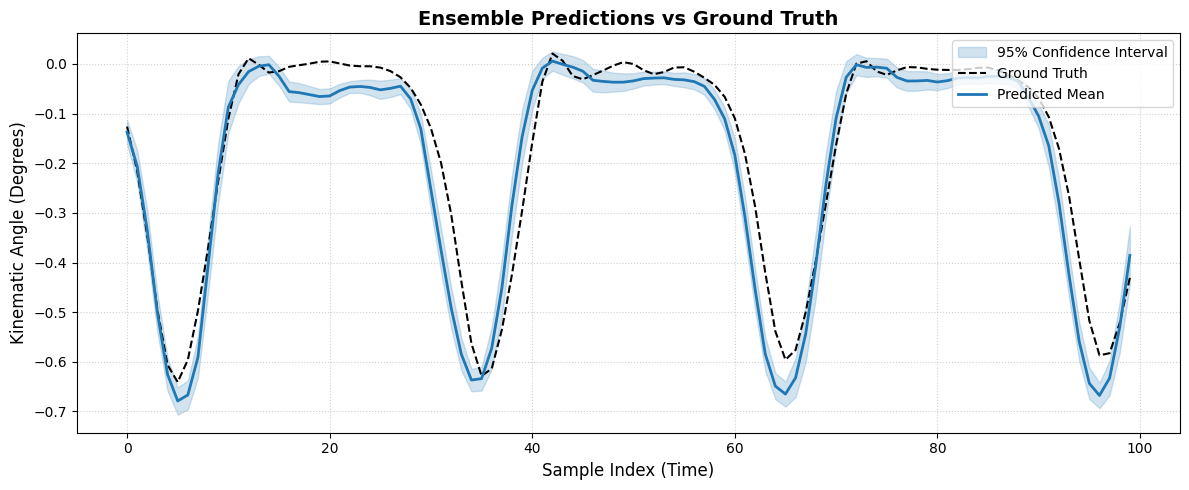


📊 EVALUATION REPORT: Ensemble
[Angle_0] RMSE: 0.0574 | NRMSE: 0.1790 | R2: 0.9680
[Angle_1] RMSE: 0.0520 | NRMSE: 0.1651 | R2: 0.9728
[Total] RMSE: 0.0547 | NRMSE: 0.1723 | R2: 0.9703

[Uncertainty] Coverage ECE: 0.1980
[Uncertainty] Sparsification Error: 0.0217



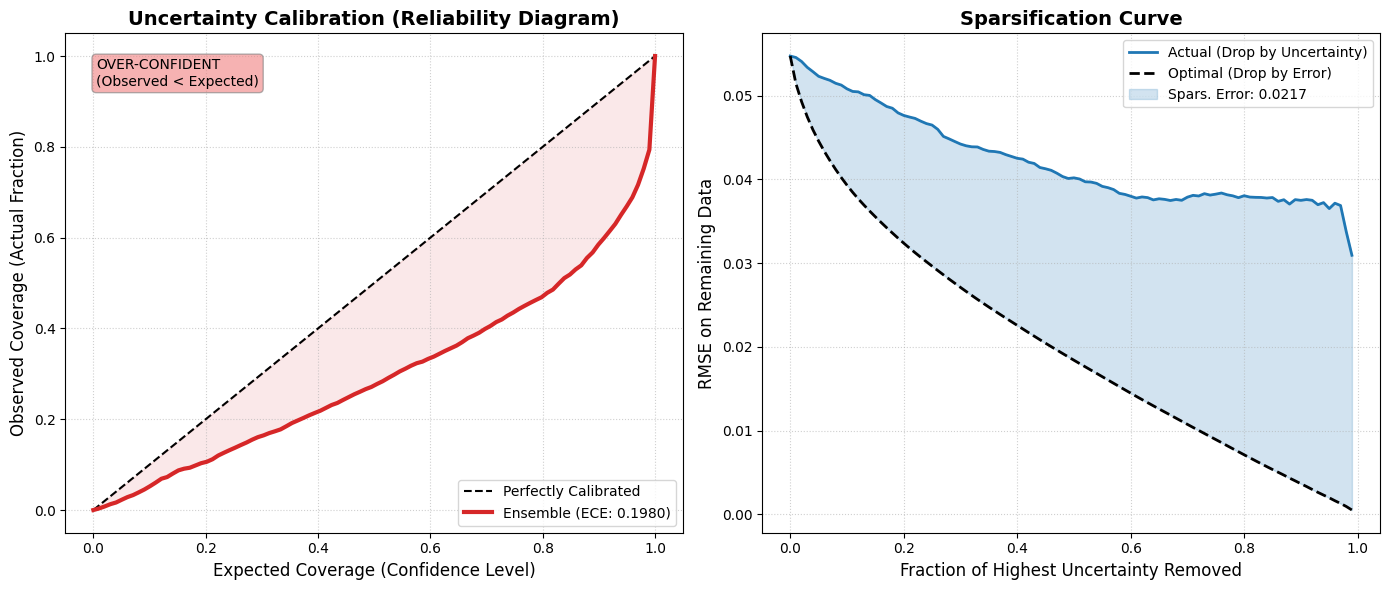

In [21]:
plot_predictions_with_uncertainty(results_file)
evaluate_and_plot(results_file)